In [1]:
import pandas as pd

In [2]:
def load_data():
    url = "heart.csv"
    df = pd.read_csv(url)
    return df
df = load_data()
print ("Shape: ", df.shape)
df.head()

Shape:  (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


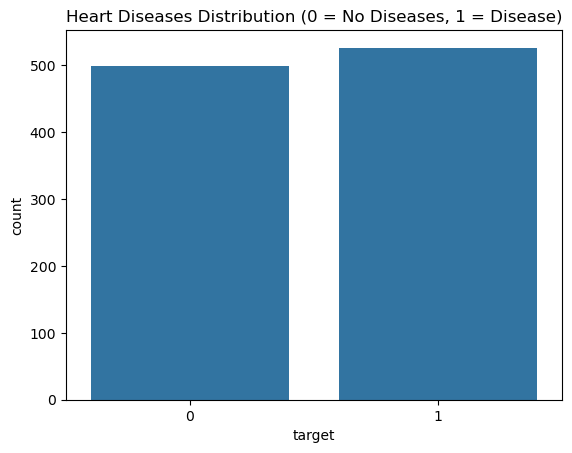

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt 
sns.countplot(x='target', data =df)
plt.title("Heart Diseases Distribution (0 = No Diseases, 1 = Disease)")
plt.show()

In [6]:
# Split Data
from sklearn.model_selection import train_test_split

def split_data(df):
    X = df.drop ('target', axis = 1)
    y = df['target']
    return train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

X_train, X_test, y_train, y_test = split_data(df)




In [7]:
#Random Forest (for Comparison)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, classification_report

def train_random_forest (X_train, y_train,X_test,y_test):
    rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    acc = accuracy_score(y_test, preds)
    return acc,preds

rf_acc, rf_preds = train_random_forest(X_train, y_train, X_test, y_test)
print ("random forest accuracy:", rf_acc)


random forest accuracy: 0.926829268292683


In [8]:
rf_preds

array([0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 1, 1])